# Live-pool validation — does the cite-budget model earn its keep on the live path?

The verdict notebook for the two Backlog tickets under *Citations & graph data*
(the live-path age-origin ticket and the corpus-models ticket). Every term used
here is defined in [`docs/landmark-vocabulary.md`](../../docs/landmark-vocabulary.md);
the two that matter most:

- **STOP rule** (`citers_before_overflow_*`) — walk the ranked citers, bucket by
  publication year, quit the instant a bucket overflows the cap of 12. Returns a
  count. It is the model's **training label**; no serving path uses it.
- **age origin** — which paper's year the model's `age` feature is measured from.
  Older notes call switching it "re-anchoring".

The collector (`src/ml_pipelines/live_pool_validation/collect.py`, run on the
corpus machine) simulated, for every `cite_budget` seed, **the exact pool the live
S2 fallback would hold** — the newest 9,000 citers — and recorded the rules run
exactly alongside the model's prediction from both age origins. Three questions:

1. **Null hypothesis:** does `predicted_budget_age_from_oldest_citer` just track
   `citers_before_overflow_reachable` — the number the serve path can compute
   exactly, for free, because it already holds the pool? If yes, the model is
   redundant on the live path (`docs/predict-vs-compute.md`).
2. **The broken baseline:** `predicted_budget_age_from_seed` against the same
   label — the pre-v5.5.0 behavior, expected to overshoot on truncated old seeds.
3. **Corpus ticket:** does `predicted_budget_age_from_seed` track
   `citers_before_overflow_full` (the label over the corpus's full ranked pool)?
   The model's premise *should* hold there — this measures it.

Plus an eyeball table of the four worked-example seeds' `band_start` (the
latest-gap tau rule on truncated-pool landmarks — fit on whole-history
distributions, so the transfer is checked by eye, not assumed).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CORPUS = Path("../../src/ml_pipelines/live_pool_validation/corpus.csv")
if not CORPUS.exists():
    raise FileNotFoundError(
        f"{CORPUS} not collected yet — run "
        "`uv run python -m ml_pipelines.live_pool_validation.collect` "
        "on the machine that holds the ingested corpus, commit corpus.csv, "
        "then re-run this notebook."
    )
corpus = pd.read_csv(CORPUS)
print(f"{len(corpus)} seeds ({int(corpus['truncated'].sum())} truncated, "
      f"{int(corpus['is_worked_example'].sum())} worked examples)")
corpus.head()

58 seeds (18 truncated, 4 worked examples)


,work_id,label,is_worked_example,arxiv_id,doi,corpus_id,s2_year,s2_citation_count,citer_count,pool_size,...,oldest_pool_year,newest_pool_year,citers_before_overflow_reachable,selected_up_to_cap_per_year,predicted_budget_age_from_seed,predicted_budget_age_from_oldest_citer,citers_before_overflow_full,corpus_rank_pool,band_start,landmark_max_year
0,W2090386790,Hawking Radiation,1,NaN,10.1007/bf02345020,55539246,1975,10825,10724,9000,...,1998,2026,143,348,160,101,175,500,2026,2026
1,W2145339207,DQN,1,NaN,10.1038/nature14236,205242740,2015,32216,31878,9000,...,2023,2026,22,48,60,39,44,500,2026,2026
2,W2794643322,QMIX,1,1803.11485,10.48550/arxiv.1803.11485,4533648,2018,2046,2008,2008,...,2018,2026,36,108,45,45,36,500,2026,2026
3,W2626778328,Attention Is All You Need,1,1706.03762,10.65215/2q58a426,13756489,2017,183110,180215,9000,...,2026,2026,12,12,59,36,46,500,2026,2026
4,W2056095744,Photoionization of the Noble Gases: Cross Sect...,0,NaN,10.1103/physreva.5.227,120884563,1972,303,301,301,...,1972,2024,166,274,158,158,168,301,2022,2024


## The worked-example seeds, side by side

The four hand-picked examples first — if a number here looks absurd, no aggregate
metric below can redeem it (the OpenAlex-misdate lesson).

In [2]:
WORKED_EXAMPLE_COLUMNS = [
    "label", "s2_year", "s2_citation_count", "citer_count", "truncated",
    "oldest_pool_year", "citers_before_overflow_reachable",
    "selected_up_to_cap_per_year", "predicted_budget_age_from_oldest_citer",
    "predicted_budget_age_from_seed", "citers_before_overflow_full",
    "band_start", "landmark_max_year",
]
corpus[corpus["is_worked_example"] == 1][WORKED_EXAMPLE_COLUMNS]

,label,s2_year,s2_citation_count,citer_count,truncated,oldest_pool_year,citers_before_overflow_reachable,selected_up_to_cap_per_year,predicted_budget_age_from_oldest_citer,predicted_budget_age_from_seed,citers_before_overflow_full,band_start,landmark_max_year
0,Hawking Radiation,1975,10825,10724,1,1998,143,348,101,160,175,2026,2026
1,DQN,2015,32216,31878,1,2023,22,48,39,60,44,2026,2026
2,QMIX,2018,2046,2008,0,2018,36,108,45,45,36,2026,2026
3,Attention Is All You Need,2017,183110,180215,1,2026,12,12,36,59,46,2026,2026


## Q1 + Q2 — both age origins against the number we can just compute

Each point is a seed. The x-axis is `citers_before_overflow_reachable`: the STOP
rule **run exactly** over the truncated pool — not an estimate, the real answer,
free at serve time because the pool is already in memory. The diagonal is
therefore a perfect prediction.

To be an improvement, the oldest-citer age origin has to hug the diagonal *better
than the seed origin*. But note the trap in the null hypothesis: if it hugs the
diagonal closely, that makes the model **redundant**, not vindicated — you'd be
paying model error to reproduce a number you already have.

Caveat on "exact": it is exact **about the truncated pool**, which for a
mega-cited seed can be a single year of citers. Exactness is a claim about the
arithmetic, not about the pool being representative.

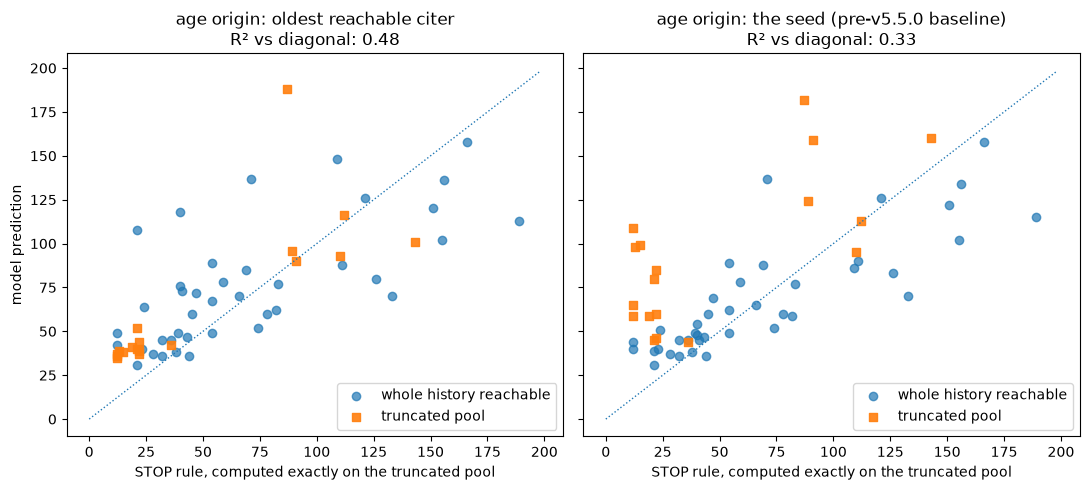

In [3]:
def diagonal_fit(observed: pd.Series, predicted: pd.Series) -> float:
    """R² of `predicted` against the y=x diagonal (not a refit line)."""
    mask = observed.notna() & predicted.notna()
    residual = ((predicted[mask] - observed[mask]) ** 2).sum()
    total = ((observed[mask] - observed[mask].mean()) ** 2).sum()
    return 1 - residual / total if total else float("nan")


LABEL = "citers_before_overflow_reachable"

figure, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for axis, column, title in [
    (axes[0], "predicted_budget_age_from_oldest_citer",
     "age origin: oldest reachable citer"),
    (axes[1], "predicted_budget_age_from_seed",
     "age origin: the seed (pre-v5.5.0 baseline)"),
]:
    truncated = corpus["truncated"] == 1
    axis.scatter(corpus.loc[~truncated, LABEL], corpus.loc[~truncated, column],
                 label="whole history reachable", alpha=0.7)
    axis.scatter(corpus.loc[truncated, LABEL], corpus.loc[truncated, column],
                 label="truncated pool", alpha=0.9, marker="s")
    limit = max(corpus[LABEL].max(), corpus[column].max()) * 1.05
    axis.plot([0, limit], [0, limit], linestyle=":", linewidth=1)
    axis.set_title(f"{title}\nR² vs diagonal: "
                   f"{diagonal_fit(corpus[LABEL], corpus[column]):.2f}")
    axis.set_xlabel("STOP rule, computed exactly on the truncated pool")
    axis.legend()
axes[0].set_ylabel("model prediction")
figure.tight_layout()

## Q3 — the corpus ticket: the model on full-history corpus pools

Unlike the live path, the corpus path **cannot** compute the label at serve time:
it pushes a limit into a ranked DuckDB query and has no citers in hand when it
does. A count is all a query can take, so here a prediction genuinely earns its
keep — if it works.

The model's premise (labels collected over whole-history rankings) *should*
transfer from OpenAlex pools to corpus pools, since both are ranked over a seed's
whole history. This is the measurement the corpus ticket asked for: seed-origin
predictions against `citers_before_overflow_full`.

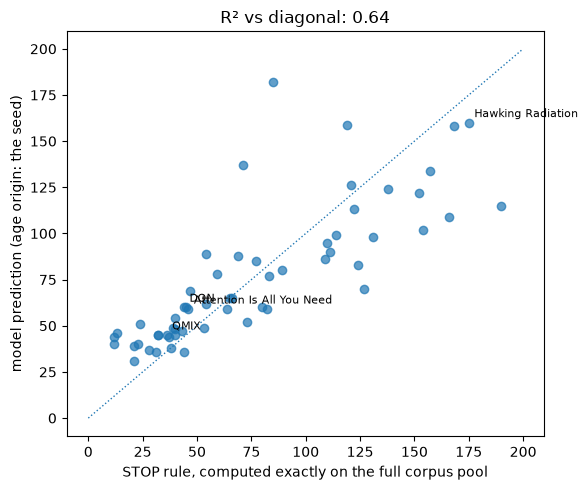

In [4]:
FULL_LABEL = "citers_before_overflow_full"
SEED_ORIGIN = "predicted_budget_age_from_seed"

figure, axis = plt.subplots(figsize=(6, 5))
axis.scatter(corpus[FULL_LABEL], corpus[SEED_ORIGIN], alpha=0.7)
for _, example in corpus[corpus["is_worked_example"] == 1].iterrows():
    axis.annotate(example["label"], (example[FULL_LABEL], example[SEED_ORIGIN]),
                  fontsize=8, xytext=(4, 4), textcoords="offset points")
limit = max(corpus[FULL_LABEL].max(), corpus[SEED_ORIGIN].max()) * 1.05
axis.plot([0, limit], [0, limit], linestyle=":", linewidth=1)
axis.set_xlabel("STOP rule, computed exactly on the full corpus pool")
axis.set_ylabel("model prediction (age origin: the seed)")
axis.set_title(f"R² vs diagonal: "
               f"{diagonal_fit(corpus[FULL_LABEL], corpus[SEED_ORIGIN]):.2f}")
figure.tight_layout()

## Verdict

*(Not yet written. The corpus was collected 2026-07-16 and the plots above are
measured, but the conclusion is a judgement call and hasn't been made — nor
carried back into the two Backlog tickets. The framing to answer against:)*

- **Q1/Q2:** if `predicted_budget_age_from_oldest_citer` tracks
  `citers_before_overflow_reachable` closely, the null hypothesis stands — the
  live path keeps its exact selection and the model stays off it
  (`docs/predict-vs-compute.md`); the oldest-citer age origin is then recorded as
  validated-but-unneeded. If it *diverges* while the seed origin diverges worse,
  moving the age origin is a real repair wherever a pre-fetch estimate is needed.
- **Q3:** if the diagonal R² is healthy and the worked examples sane, the corpus
  path can keep `predicted_budget` as its landmark total; if not, the corpus
  ticket's fallback applies (run the SKIP rule over a corpus pool — it's local
  too).
- **Band starts:** eyeball the worked examples' `band_start` against where their
  landmark clusters actually thin out. A boundary pinned to the `max_span` floor
  on every truncated seed would mean the tau rule doesn't transfer — and so would
  the opposite degeneracy, every seed collapsing onto the newest year.